In [15]:
import math
from datetime import timedelta
from operator import attrgetter
import matplotlib.pyplot as plt
import numpy as np
import trajan as ta
import xarray as xr
from IPython.display import HTML
import zarr
from matplotlib.animation import FuncAnimation
import parcels
from mpl_toolkits.mplot3d import Axes3D

In [37]:
# Define the new Kernel that mimics Argo vertical movement
def Seagliderspatialmovement(particle, fieldset, time):
    maxdepth = 200.0
    vertical_velocity = 0.20  # m/s

    if particle.cycle_phase == 0:  # descending

        particle_ddepth += vertical_velocity * particle.dt

        if particle.depth + particle_ddepth >= maxdepth:
            particle_ddepth = maxdepth - particle.depth
            particle.cycle_phase = 1

    elif particle.cycle_phase == 1:  # ascending

        particle_ddepth -= vertical_velocity * particle.dt

        if particle.depth + particle_ddepth <= fieldset.mindepth:
            particle_ddepth = fieldset.mindepth - particle.depth
            particle.cycle_phase = 0

<xarray.DataArray 'z' ()> Size: 4B
dask.array<_nanmin_skip-aggregate, shape=(), dtype=float32, chunksize=(), chunktype=numpy.ndarray>
Coordinates:
    trajectory  int64 8B 4
Attributes:
    long_name:      
    positive:       down
    standard_name:  depth
    units:          m <xarray.DataArray 'z' ()> Size: 4B
dask.array<_nanmax_skip-aggregate, shape=(), dtype=float32, chunksize=(), chunktype=numpy.ndarray>
Coordinates:
    trajectory  int64 8B 4
Attributes:
    long_name:      
    positive:       down
    standard_name:  depth
    units:          m


In [33]:
# Load the GlobCurrent data in the Agul1has region from the example_data
example_dataset_folder = parcels.download_example_dataset("GlobCurrent_example_data")
filenames = {
    "U": f"{example_dataset_folder}/20*.nc",
    "V": f"{example_dataset_folder}/20*.nc",
}
variables = {
    "U": "eastward_eulerian_current_velocity",
    "V": "northward_eulerian_current_velocity",
}
dimensions = {"lat": "lat", "lon": "lon", "time": "time"}
fieldset = parcels.FieldSet.from_netcdf(filenames, variables, dimensions)
# uppermost layer in the hydrodynamic data
fieldset.mindepth = fieldset.U.depth[0]




# Define a new Particle type including extra Variables
SeagliderParticle = parcels.JITParticle.add_variables(
    [
        # Phase of cycle:
        # init_descend=0,
        # drift=1,
        # profile_descend=2,
        # profile_ascend=3,
        # transmit=4
        parcels.Variable("cycle_phase", dtype=np.int32, initial=0.0),
        parcels.Variable("drift_age", dtype=np.float32, initial=0.0),
        # if fieldset has temperature
        # Variable('temp', dtype=np.float32, initial=np.nan),
    ]
)

# Initiate one Argo float in the Agulhas Current
pset = parcels.ParticleSet(
    fieldset=fieldset, pclass=SeagliderParticle, lon=[32], lat=[-31], depth=[0]
)

# combine Argo vertical movement kernel with built-in Advection kernel
kernels = pset.Kernel(Seagliderspatialmovement) + parcels.AdvectionRK4



# Create a ParticleFile object to store the output
output_file = pset.ParticleFile(
    name="seaglider_float",
    outputdt=timedelta(minutes=15),
    chunks=(1, 500),  # setting to write in chunks of 500 observations
)

# Now execute the kernels for 30 days, saving data every 30 minutes
pset.execute(
    kernels,
    runtime=timedelta(days=30),
    dt=timedelta(minutes=15),
    output_file=output_file,
)

INFO: Output files are stored in seaglider_float.zarr.
100%|█████████████████████████| 2592000.0/2592000.0 [00:05<00:00, 444032.40it/s]


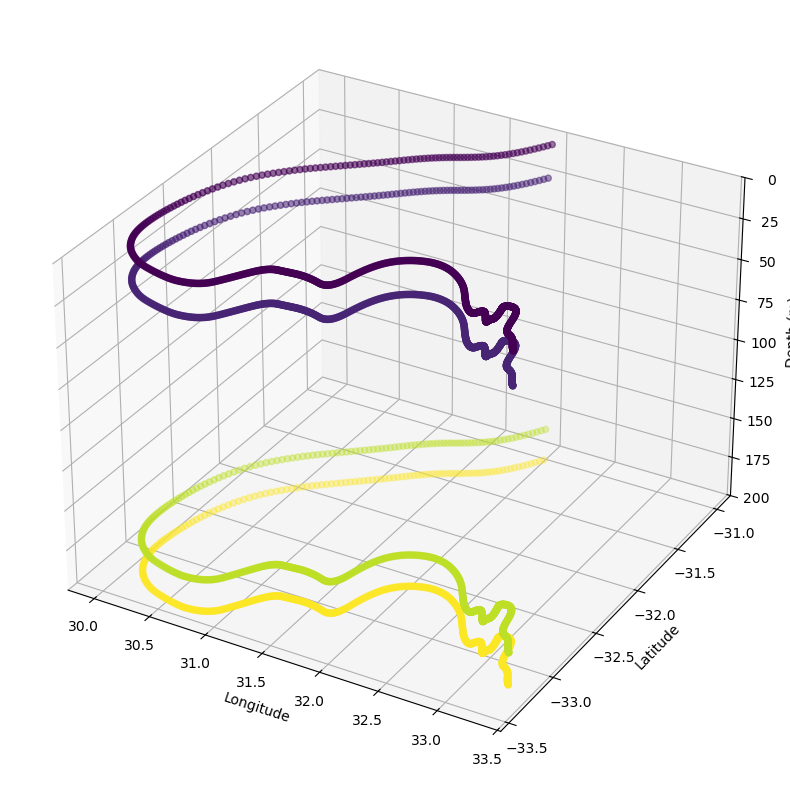

<xarray.DataArray 'z' ()> Size: 4B
dask.array<_nanmin_skip-aggregate, shape=(), dtype=float32, chunksize=(), chunktype=numpy.ndarray>
Coordinates:
    trajectory  int64 8B 8
Attributes:
    long_name:      
    positive:       down
    standard_name:  depth
    units:          m <xarray.DataArray 'z' ()> Size: 4B
dask.array<_nanmax_skip-aggregate, shape=(), dtype=float32, chunksize=(), chunktype=numpy.ndarray>
Coordinates:
    trajectory  int64 8B 8
Attributes:
    long_name:      
    positive:       down
    standard_name:  depth
    units:          m


In [38]:
ds = xr.open_zarr("seaglider_float.zarr")
x = ds["lon"][:].squeeze()
y = ds["lat"][:].squeeze()
z = ds["z"][:].squeeze()
ds.close()

fig = plt.figure(figsize=(13, 10))
ax = plt.axes(projection="3d")
cb = ax.scatter(x, y, z, c=z, s=20, marker="o")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_zlabel("Depth (m)")
ax.set_zlim(np.max(z), 0)
plt.show()

print(np.min(z), np.max(z))